## Importación, configuración y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("..\Data\marketing_campaign_dataset.csv")
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


## Exploración inicial (EDA básico)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  str    
 2   Campaign_Type     200000 non-null  str    
 3   Target_Audience   200000 non-null  str    
 4   Duration          200000 non-null  str    
 5   Channel_Used      200000 non-null  str    
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  str    
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  str    
 10  Language          200000 non-null  str    
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  str    
 15  Date              200000 non-null  str    
dtypes: float64(2), int64(4), str(10

In [3]:
df.describe()

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,0.080070,5.002438,549.772030,5507.301520,5.494710
std,57735.171256,0.040602,1.734488,260.019056,2596.864286,2.872581
min,1.000000,0.010000,2.000000,100.000000,1000.000000,1.000000
25%,50000.750000,0.050000,3.500000,325.000000,3266.000000,3.000000
50%,100000.500000,0.080000,5.010000,550.000000,5517.500000,5.000000
75%,150000.250000,0.120000,6.510000,775.000000,7753.000000,8.000000
max,200000.000000,0.150000,8.000000,1000.000000,10000.000000,10.000000


In [4]:
df.isnull().sum()

Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

## Limpieza de datos

In [5]:
# Convertir 'Date' a formato datetime
df['Date'] = pd.to_datetime(df['Date'])

# Convertir 'Acquisition_Cost' a numérico, eliminando símbolos de moneda y comas
df['Acquisition_Cost'] = (
    df['Acquisition_Cost']
    .replace('[\$,]', '', regex=True)  # elimina $ y comas
    .astype(float)
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Campaign_ID       200000 non-null  int64         
 1   Company           200000 non-null  str           
 2   Campaign_Type     200000 non-null  str           
 3   Target_Audience   200000 non-null  str           
 4   Duration          200000 non-null  str           
 5   Channel_Used      200000 non-null  str           
 6   Conversion_Rate   200000 non-null  float64       
 7   Acquisition_Cost  200000 non-null  float64       
 8   ROI               200000 non-null  float64       
 9   Location          200000 non-null  str           
 10  Language          200000 non-null  str           
 11  Clicks            200000 non-null  int64         
 12  Impressions       200000 non-null  int64         
 13  Engagement_Score  200000 non-null  int64         
 14  Customer_Segmen

In [6]:
# Verificar duplicados
df.duplicated().sum()

np.int64(0)

## Feature Engineering

In [7]:
# Calcular Tasa de Clicks (CTR)
df['CTR'] = df['Clicks'] / df['Impressions']

# Calcular Conversiones Estimadas
df['Estimated_Conversions'] = df['Clicks'] * df['Conversion_Rate']

# Calcular Costo por Adquisición (CPA)
df['CPA'] = df['Acquisition_Cost'] / df['Estimated_Conversions']

# Evitar divisiones por cero o valores infinitos en CPA
df['CPA'] = df['CPA'].replace([np.inf, -np.inf], np.nan)
df.dropna(subset=['CPA'], inplace=True)

# Mostrar las nuevas columnas
df[['CTR','Estimated_Conversions', 'CPA']].head()

,CTR,Estimated_Conversions,CPA
0,0.263267,20.24,799.110672
1,0.015419,13.92,830.890805
2,0.075864,40.88,249.510763
3,0.119231,23.87,533.054043
4,0.090217,18.95,868.179420


## Análisis Exploratorio (EDA)

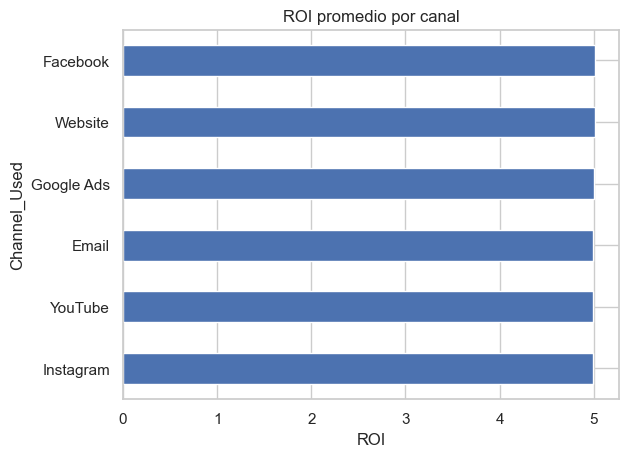

In [8]:
# Configuración visual
sns.set(style="whitegrid")

# ROI promedio por canal
roi_channel = df.groupby('Channel_Used')['ROI'].mean().sort_values()

roi_channel.plot(kind='barh')
plt.title("ROI promedio por canal")
plt.xlabel("ROI")
plt.show()

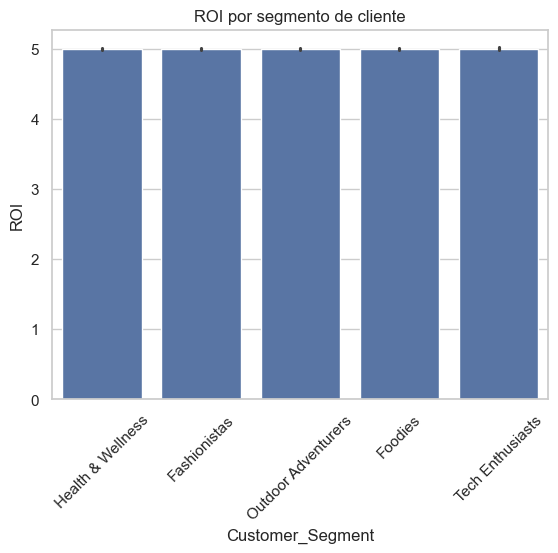

In [9]:
# ROI por segmento de cliente
sns.barplot(x='Customer_Segment', y='ROI', data=df)
plt.xticks(rotation=45)
plt.title("ROI por segmento de cliente")
plt.show()

El ROI presenta una distribución prácticamente constante a través de canales y segmentos, lo que sugiere que esta métrica no está capturando adecuadamente las diferencias en desempeño entre campañas.

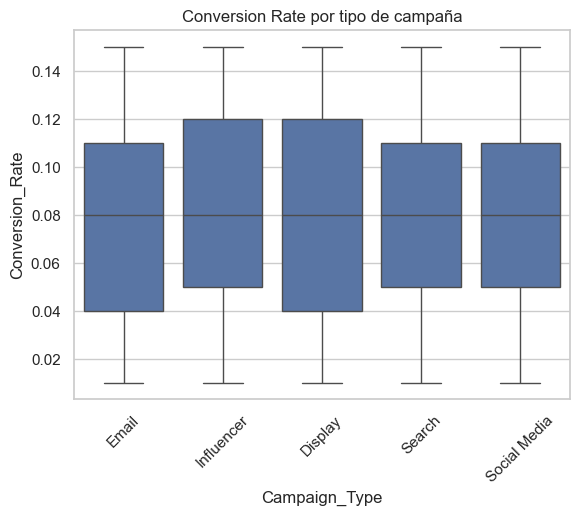

In [10]:
# Conversion Rate por tipo de campaña
sns.boxplot(x='Campaign_Type', y='Conversion_Rate', data=df)
plt.xticks(rotation=45)
plt.title("Conversion Rate por tipo de campaña")
plt.show()

No se observan diferencias significativas en conversion rate entre tipos de campaña, lo que indica que el tipo de campaña por sí solo no es un factor determinante del rendimiento.

## Análisis avanzado 

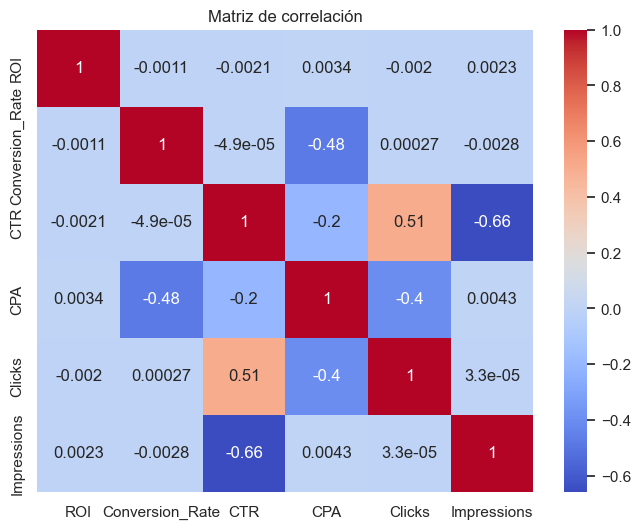

In [12]:
# Correlation Analysis
corr = df[['ROI', 'Conversion_Rate', 'CTR', 'CPA', 'Clicks', 'Impressions']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

Hallazgos:

* CTR vs Clicks → 0.51 (positiva fuerte)
    Lógico: más CTR → más clicks

* CTR vs Impressions → -0.66 (negativa fuerte)
    A mayor volumen de impresiones, menor CTR
    Es decir: campañas masivas → menos engagement

* CPA vs Conversion Rate → -0.48
    A mayor conversion rate, menor costo por adquisición

El análisis de correlación muestra que el Conversion Rate es el principal driver de eficiencia, ya que impacta negativamente el CPA, reduciendo el costo por adquisición.

Problema del dataset:

* ROI ≈ constante
* Conversion Rate ≈ similar
* No hay diferenciación clara

El dataset presenta baja variabilidad en métricas clave, lo que limita la capacidad de identificar factores determinantes del rendimiento.

Por ende, debido a la baja variabilidad en métricas clave como ROI y Conversion Rate, se recomienda enriquecer el análisis incorporando variables adicionales o redefiniendo métricas que permitan una mejor segmentación del rendimiento.

In [13]:
# Campañas ineficientes: ROI negativo y CPA por encima del promedio
inefficient = df[(df['ROI'] < 0) & (df['CPA'] > df['CPA'].mean())]
inefficient[['Campaign_Type', 'Channel_Used', 'ROI', 'CPA']].head()

,Campaign_Type,Channel_Used,ROI,CPA


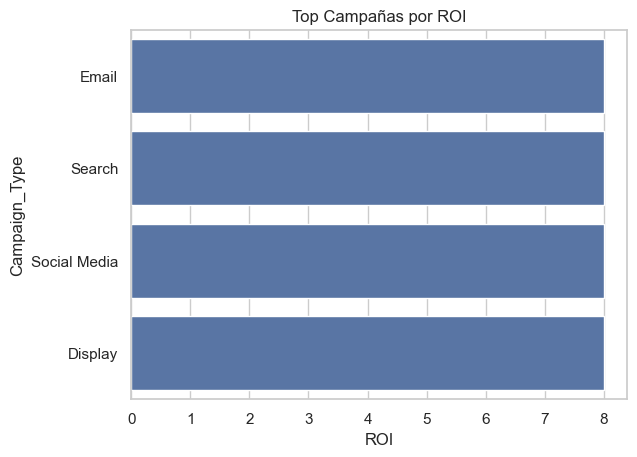

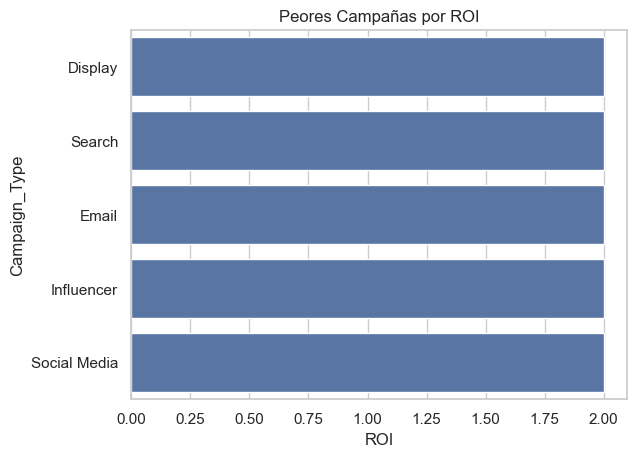

In [18]:
# Top & Bottom Campaigns
top_campaigns = df.sort_values(by='ROI', ascending=False).head(10)
bottom_campaigns = df.sort_values(by='ROI').head(10)

# Visualización de campañas top y bottom
plt.figure()
sns.barplot(x='ROI', y='Campaign_Type', data=top_campaigns)
plt.title("Top Campañas por ROI")
plt.show()

plt.figure()
sns.barplot(x='ROI', y='Campaign_Type', data=bottom_campaigns)
plt.title("Peores Campañas por ROI")
plt.show()

La identificación de campañas top y bottom no es significativa debido a la homogeneidad del ROI, lo que sugiere que esta métrica no es adecuada para priorización

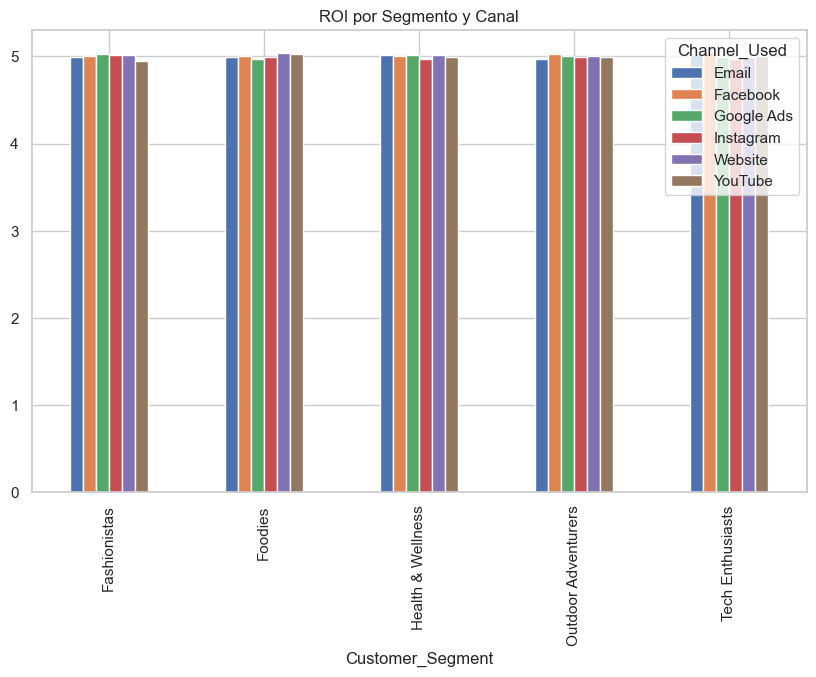

In [15]:
# Segment Performance
segment_analysis = df.groupby(['Customer_Segment', 'Channel_Used'])['ROI'].mean().unstack()
segment_analysis.plot(kind='bar', figsize=(10,6))
plt.title("ROI por Segmento y Canal")
plt.show()

No se observa interacción significativa entre segmento de cliente y canal, lo que indica que la segmentación actual no está aportando valor analítico.

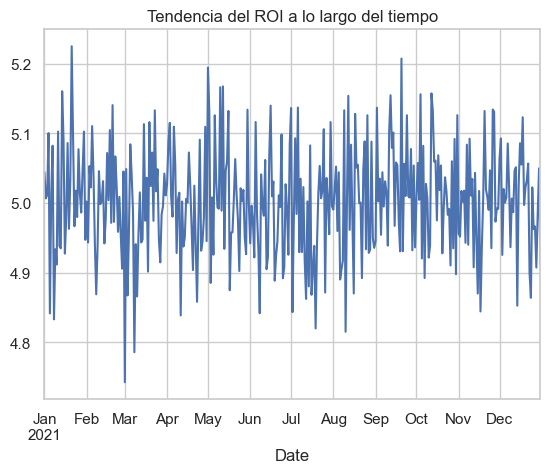

In [16]:
# Análisis de series temporales
time_trend = df.groupby('Date')['ROI'].mean()
time_trend.plot()
plt.title("Tendencia del ROI a lo largo del tiempo")
plt.show()

No se identifican tendencias temporales ni estacionalidad en el ROI, lo que limita el análisis de optimización en el tiempo.

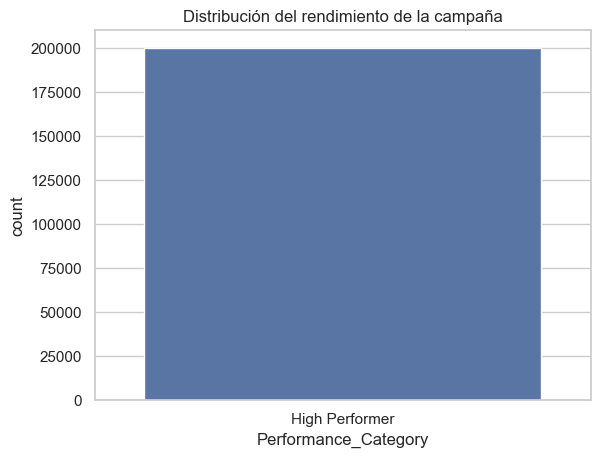

In [17]:
# Clasificación de campañas

def classify_campaign(row):
    if row['ROI'] > 0.3:
        return "High Performer"
    elif row['ROI'] > 0:
        return "Moderate"
    else:
        return "Low Performer"

df['Performance_Category'] = df.apply(classify_campaign, axis=1)
df['Performance_Category'].value_counts()

sns.countplot(x='Performance_Category', data=df)
plt.title("Distribución del rendimiento de la campaña")
plt.show()

La clasificación no es útil debido a la falta de dispersión en el ROI, lo que sugiere que los umbrales definidos no permiten discriminar entre niveles de desempeño.

El dataset presenta una estructura simulada con baja variabilidad en métricas clave, lo que limita su uso para análisis predictivo o toma de decisiones estratégicas.